# reward-habits-opinion-network — обробка результатів BehaviorSpace

Читає вивід семи експериментів (`E1`–`E7`) моделі
`reward-habits-opinion-network-simplified`. Файли — стандартний
"table"-експорт BehaviorSpace: `e{N}-table.csv` у тій самій теці, що й
цей ноутбук, преамбула рівно 6 рядків.

`E7 Big factorial` ще рахується на момент написання — ноутбук читає
його, якщо файл `e7-table.csv` вже з'явився, і акуратно пропускає цей
розділ з поясненням, якщо ні. Решту клітинок можна виконувати незалежно
від того, чи готовий E7.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

try:
    import statsmodels.api as sm
    from statsmodels.formula.api import ols
    HAVE_STATSMODELS = True
except ImportError:
    HAVE_STATSMODELS = False
    warnings.warn("statsmodels не встановлено — двофакторний ANOVA у E3 "
                   "буде замінено на bootstrap CI взаємодії.")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# --------------------------------------------------------------------
# CONFIG
# --------------------------------------------------------------------
DATA_DIR = Path("./experiments/new-1")          # тека з e1-table.csv .. e7-table.csv
PREAMBLE_ROWS = 6             # підтверджено на реальних файлах
CI_LEVEL = 0.95
SAVE_FIGS = False
FIG_DIR = Path("figures")
if SAVE_FIGS:
    FIG_DIR.mkdir(exist_ok=True)

# Розклад фаз моделі (з code.nls): baseline | [campaign+withdrawal] x cycles.
# Використовується лише для ліній/заливки меж фаз на графіках E2.
SCHEDULE = dict(baseline=30, campaign=60, withdrawal=100, cycles=3)
SALIENCE_THRESHOLD = 0.60   # константа моделі, перемикає знак crowding-out

## Завантаження

`skiprows=6` — саме стільки рядків преамбули в реальних файлах
(перевірено вручну на всіх шести). Про всяк випадок код перевіряє, що
рядок 7 дійсно є заголовком `[run number]`, і кидає зрозумілу помилку,
якщо ні — замість тихого зсуву колонок.

Назви колонок очищуються в `snake_case`
(`campaign-lift` → `campaign_lift`, `program-on?` → `program_on`,
`[step]` → `step`), типи приводяться: `program_on`/`wom_on` → `bool`,
текстові категорійні колонки → `category`.

In [2]:
def read_bs_table(path: Path, skiprows: int = PREAMBLE_ROWS) -> pd.DataFrame:
    with open(path, encoding="utf-8") as f:
        for _ in range(skiprows):
            f.readline()
        header_line = f.readline()
    if not (header_line.lstrip().startswith('[run number]')
            or header_line.lstrip().startswith('"[run number]"')):
        raise ValueError(
            f"Рядок {skiprows + 1} у {path} не схожий на заголовок BehaviorSpace "
            f"('[run number]' не знайдено). Преамбула, можливо, іншої довжини — "
            f"перевірте PREAMBLE_ROWS. Отримано: {header_line[:80]!r}"
        )
    return pd.read_csv(path, skiprows=skiprows)


def snake(name: str) -> str:
    s = str(name).strip()
    s = s.replace("[", "").replace("]", "").replace('"', " ")
    s = re.sub(r"[^0-9a-zA-Z]+", "_", s)
    return re.sub(r"_+", "_", s).strip("_").lower()


BOOL_COLS = ["program_on", "wom_on"]
CATEGORY_COLS = ["contagion_rule", "network_topology", "initial_opinion_distribution"]


def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [snake(c) for c in df.columns]
    return df


def coerce_types(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for c in BOOL_COLS:
        if c in df.columns and df[c].dtype == object:
            df[c] = (df[c].astype(str).str.strip().str.strip('"').str.lower()
                        .map({"true": True, "false": False}))
    for c in CATEGORY_COLS:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip().str.strip('"').astype("category")
    handled = set(BOOL_COLS) | set(CATEGORY_COLS)
    for c in df.columns:
        if c in handled:
            continue
        if df[c].dtype == object:
            converted = pd.to_numeric(
                df[c].astype(str).str.strip().str.strip('"'), errors="coerce"
            )
            if converted.notna().mean() > 0.99:
                df[c] = converted
    return df


def qa_report(df: pd.DataFrame, name: str) -> None:
    problems = []
    if "run_number" in df.columns:
        is_trajectory = "step" in df.columns and df.groupby("run_number")["step"].nunique().max() > 1
        if not is_trajectory and df["run_number"].duplicated().any():
            problems.append(f"{df['run_number'].duplicated().sum()} duplicated run_number")
    for c in BOOL_COLS:
        if c in df.columns and df[c].isna().any():
            problems.append(f"'{c}' has {df[c].isna().sum()} unparsed values")
    all_na = [c for c in df.columns if df[c].isna().all()]
    if all_na:
        problems.append(f"fully-empty columns: {all_na}")
    if problems:
        print(f"  [QA WARNING] {name}: " + "; ".join(problems))


def load_experiment(key: str):
    path = DATA_DIR / f"{key}/table.csv"
    if not path.exists():
        return None
    df = coerce_types(clean_columns(read_bs_table(path)))
    qa_report(df, key)
    return df


ALL_KEYS = ["e1", "e2", "e3", "e4", "e5", "e6", "e7"]
data = {k: load_experiment(k) for k in ALL_KEYS}

for key, df in data.items():
    if df is None:
        print(f"{key:3s}  -- файл {key}-table.csv не знайдено (ще не готовий?)")
    else:
        n_runs = df["run_number"].nunique()
        print(f"{key:3s}  rows={len(df):6d}  runs={n_runs:4d}  cols={df.shape[1]}")

e1   rows=    80  runs=  80  cols=27
e2   rows= 10220  runs=  20  cols=16
e3   rows=   160  runs= 160  cols=27
e4   rows=   480  runs= 480  cols=27
e5   rows=   270  runs= 270  cols=27
e6   rows=   720  runs= 720  cols=23
e7   rows= 28800  runs=28800  cols=26


## Спільні інструменти аналізу

In [3]:
def summarize(df: pd.DataFrame, group_cols, value_col: str, ci: float = CI_LEVEL) -> pd.DataFrame:
    g = df.groupby(group_cols, observed=True)[value_col]
    out = g.agg(n="count", mean="mean", std="std").reset_index()
    out["sem"] = out["std"] / np.sqrt(out["n"])
    tcrit = stats.t.ppf(0.5 + ci / 2, (out["n"] - 1).clip(lower=1))
    out["ci_lo"] = out["mean"] - tcrit * out["sem"]
    out["ci_hi"] = out["mean"] + tcrit * out["sem"]
    return out


def cohens_d(a, b) -> float:
    a, b = np.asarray(a, float), np.asarray(b, float)
    n1, n2 = len(a), len(b)
    pooled_sd = np.sqrt(((n1 - 1) * a.var(ddof=1) + (n2 - 1) * b.var(ddof=1)) / (n1 + n2 - 2))
    return (a.mean() - b.mean()) / pooled_sd if pooled_sd > 0 else np.nan


def compare_two_groups(df: pd.DataFrame, group_col: str, value_col: str) -> dict:
    a = df.loc[df[group_col] == True, value_col].dropna()
    b = df.loc[df[group_col] == False, value_col].dropna()
    u_stat, p_mwu = stats.mannwhitneyu(a, b, alternative="two-sided")
    return dict(
        metric=value_col, mean_true=a.mean(), mean_false=b.mean(),
        diff=a.mean() - b.mean(), cohens_d=cohens_d(a, b),
        p_mannwhitney=p_mwu, n_true=len(a), n_false=len(b),
    )


def bar_with_ci(ax, summary_df, labels=None, colors=None, title=None,
                 y="mean", lo="ci_lo", hi="ci_hi"):
    x = np.arange(len(summary_df))
    means = summary_df[y].to_numpy()
    err = np.vstack([means - summary_df[lo].to_numpy(), summary_df[hi].to_numpy() - means])
    ax.bar(x, means, yerr=err, capsize=4, color=colors, edgecolor="black", linewidth=0.8)
    ax.set_xticks(x)
    if labels is not None:
        ax.set_xticklabels(labels)
    ax.axhline(0, color="black", linewidth=0.8)
    if title:
        ax.set_title(title)
    return ax


def phase_spans(sched=SCHEDULE):
    """baseline | [campaign + withdrawal] x cycles, з code.nls."""
    spans = [("baseline", 0, sched["baseline"])]
    t = sched["baseline"]
    for _ in range(sched["cycles"]):
        spans.append(("campaign", t, t + sched["campaign"]))
        t += sched["campaign"]
        spans.append(("withdrawal", t, t + sched["withdrawal"]))
        t += sched["withdrawal"]
    return spans


PHASE_COLORS = {"campaign": "#DCEEDC", "withdrawal": "#E8E8E8"}


def shade_phases(ax, spans=None):
    for phase, start, stop in (spans or phase_spans()):
        color = PHASE_COLORS.get(phase)
        if color:
            ax.axvspan(start, stop, color=color, zorder=0)


def maybe_save(fig, name):
    if SAVE_FIGS:
        fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")

## E1 — Amplification

`wom-on?` on/off при `program-on? = true` фіксованому. Питання: чи
розмови підсилюють `campaign-lift` і `retention`.

               mean_false  mean_true      diff  cohens_d  p_mannwhitney
metric                                                                 
campaign_lift    0.769392   0.815001  0.045610  3.893358   1.667826e-14
retention        0.689033   0.844997  0.155964  7.008456   1.434074e-14


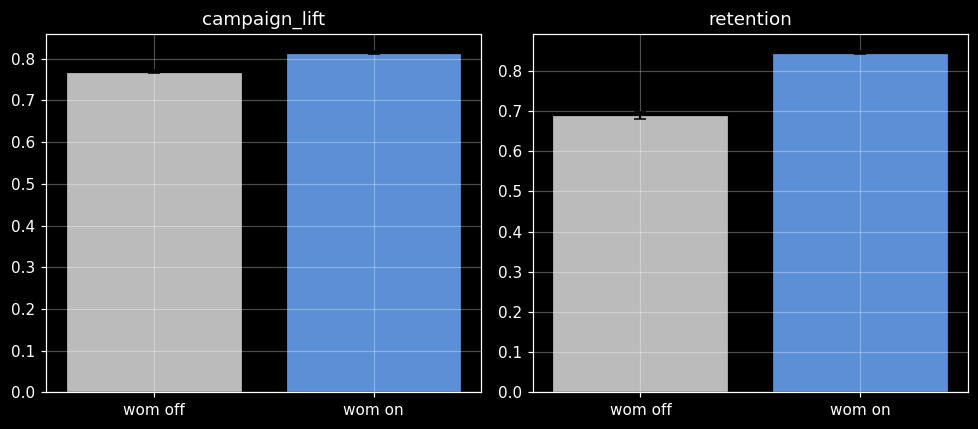

In [4]:
e1 = data["e1"]
if e1 is None:
    print("e1-table.csv відсутній — розділ пропущено.")
else:
    e1_results = pd.DataFrame([
        compare_two_groups(e1, "wom_on", m) for m in ["campaign_lift", "retention"]
    ]).set_index("metric")
    print(e1_results[["mean_false", "mean_true", "diff", "cohens_d", "p_mannwhitney"]])

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    for ax, m in zip(axes, ["campaign_lift", "retention"]):
        s = summarize(e1, ["wom_on"], m)
        bar_with_ci(ax, s, labels=["wom off", "wom on"],
                    colors=["#BBBBBB", "#5B8FD6"], title=m)
    fig.tight_layout()
    maybe_save(fig, "e1_amplification")
    plt.show()

## E2 — Persistence (per-tick trajectory)

`wom-on?` on/off, метрики записані на кожному тіку. Заливка — фази
campaign (зелене) і withdrawal (сіре), три цикли поспіль.

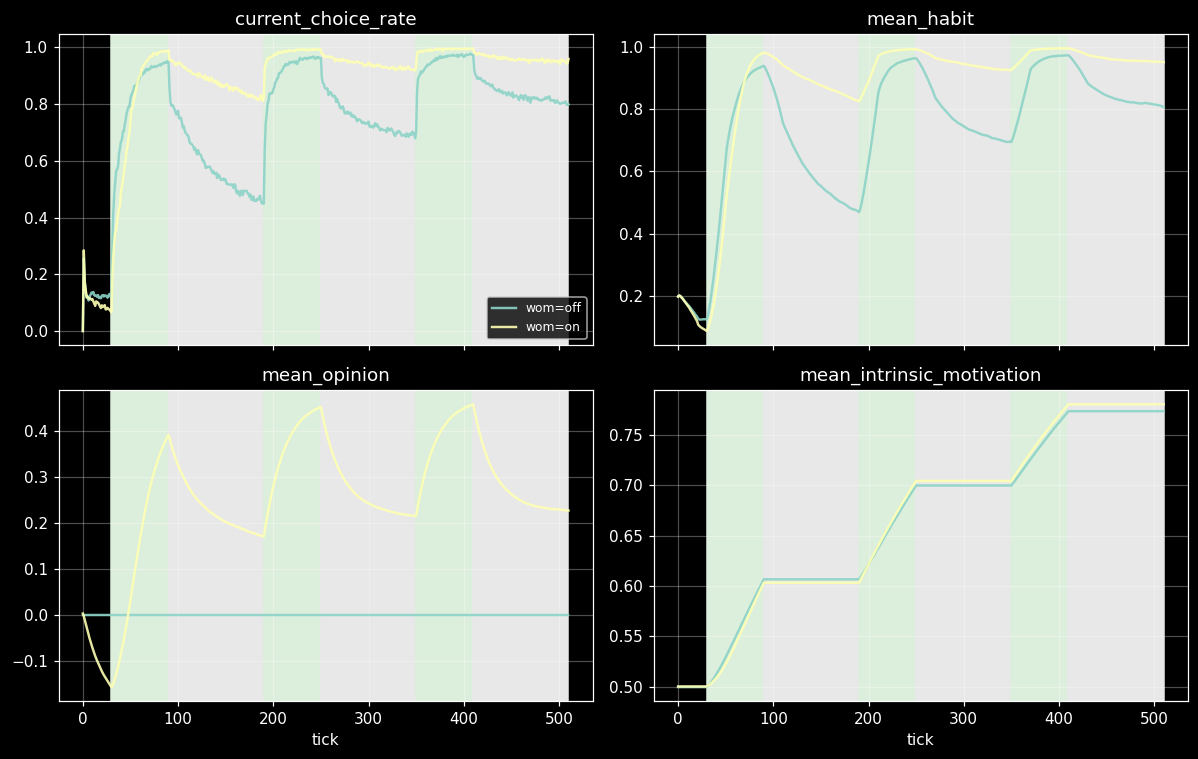

In [5]:
e2 = data["e2"]
if e2 is None:
    print("e2-table.csv відсутній — розділ пропущено.")
else:
    traj_metrics = ["current_choice_rate", "mean_habit", "mean_opinion", "mean_intrinsic_motivation"]
    traj = (e2.groupby(["wom_on", "step"], observed=True)[traj_metrics]
               .mean().reset_index())

    fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
    for ax, metric in zip(axes.flat, traj_metrics):
        shade_phases(ax)
        for wom, g in traj.groupby("wom_on", observed=True):
            ax.plot(g["step"], g[metric], label=f"wom={'on' if wom else 'off'}",
                    linewidth=1.6, alpha=0.9, zorder=2)
        ax.set_title(metric)
    axes[0, 0].legend(fontsize=8)
    for ax in axes[-1]:
        ax.set_xlabel("tick")
    fig.tight_layout()
    maybe_save(fig, "e2_persistence_trajectory")
    plt.show()

## E3 — Substitution (факторіал program × wom)

Взаємодія = `(on,on) − (on,off) − (off,on) + (off,off)`: від'ємне —
канали замінники, додатне — доповнювачі.

                off_off    off_on    on_off     on_on  interaction
metric                                                            
campaign_lift  0.010854 -0.057354  0.767409  0.816176     0.116975
retention      0.015367 -0.060258  0.695594  0.844781     0.224811

Двофакторний ANOVA для retention:
                            sum_sq     df             F         PR(>F)
C(program_on)            25.130704    1.0  96087.019309  1.465371e-219
C(wom_on)                 0.054112    1.0    206.898159   2.114239e-30
C(program_on):C(wom_on)   0.505400    1.0   1932.393687   8.703065e-90
Residual                  0.040800  156.0           NaN            NaN


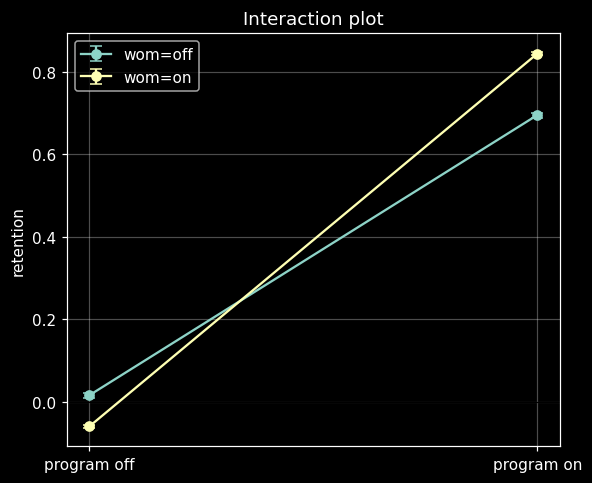

In [6]:
e3 = data["e3"]
if e3 is None:
    print("e3-table.csv відсутній — розділ пропущено.")
else:
    rows = []
    for m in ["campaign_lift", "retention"]:
        tab = e3.groupby(["program_on", "wom_on"], observed=True)[m].mean().unstack()
        interaction = tab.loc[True, True] - tab.loc[True, False] - tab.loc[False, True] + tab.loc[False, False]
        rows.append(dict(metric=m, off_off=tab.loc[False, False], off_on=tab.loc[False, True],
                          on_off=tab.loc[True, False], on_on=tab.loc[True, True],
                          interaction=interaction))
    e3_summary = pd.DataFrame(rows).set_index("metric")
    print(e3_summary)

    if HAVE_STATSMODELS:
        print("\nДвофакторний ANOVA для retention:")
        model = ols("retention ~ C(program_on) * C(wom_on)", data=e3).fit()
        print(sm.stats.anova_lm(model, typ=2))
    else:
        rng = np.random.default_rng(0)
        boot = []
        for _ in range(2000):
            s = e3.sample(frac=1, replace=True, random_state=rng.integers(0, 2**31 - 1))
            tab = s.groupby(["program_on", "wom_on"], observed=True)["retention"].mean().unstack()
            boot.append(tab.loc[True, True] - tab.loc[True, False] - tab.loc[False, True] + tab.loc[False, False])
        lo, hi = np.percentile(boot, [2.5, 97.5])
        print(f"\nBootstrap 95% CI взаємодії на retention: [{lo:.4f}, {hi:.4f}]")

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    s = summarize(e3, ["program_on", "wom_on"], "retention")
    for wom in [False, True]:
        sub = s[s.wom_on == wom].sort_values("program_on")
        ax.errorbar(sub["program_on"].astype(int), sub["mean"],
                     yerr=[sub["mean"] - sub["ci_lo"], sub["ci_hi"] - sub["mean"]],
                     marker="o", capsize=4, label=f"wom={'on' if wom else 'off'}")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["program off", "program on"])
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("retention"); ax.set_title("Interaction plot")
    ax.legend()
    fig.tight_layout()
    maybe_save(fig, "e3_interaction")
    plt.show()

## E4 — Salience sweep (crowding-out)

`reward-salience` 0.2…0.9 × `wom-on?`. Вертикальна лінія — поріг
`salience-threshold = 0.60`, де знак впливу на `mean_intrinsic_motivation`
має перемикатися.

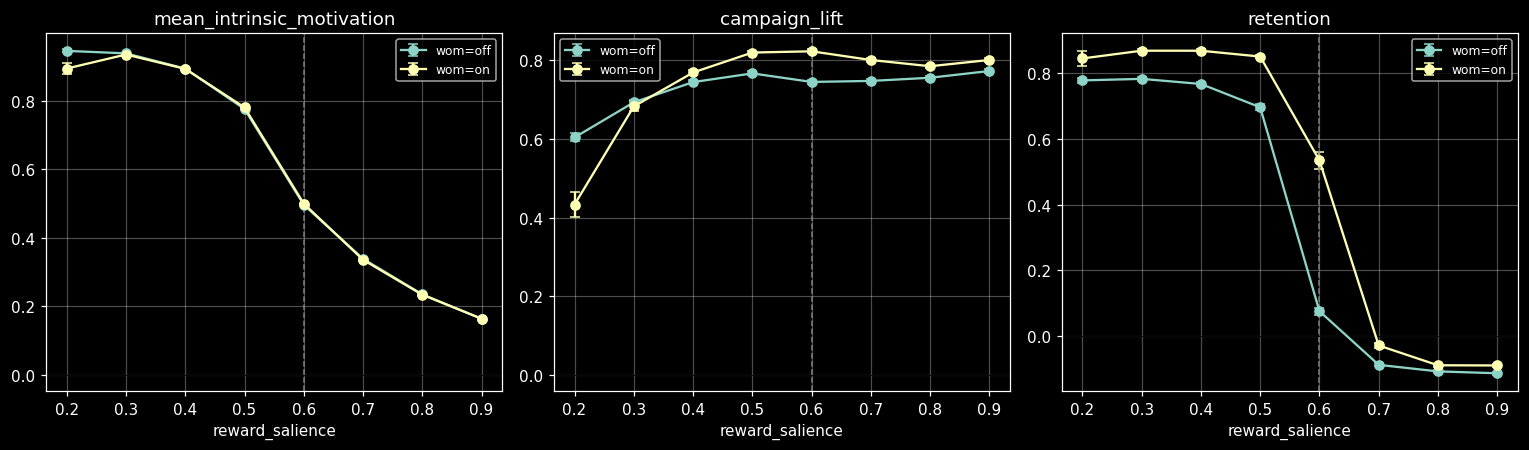

In [7]:
e4 = data["e4"]
if e4 is None:
    print("e4-table.csv відсутній — розділ пропущено.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
    metrics = ["mean_intrinsic_motivation", "campaign_lift", "retention"]
    for ax, m in zip(axes, metrics):
        for wom in [False, True]:
            sub = e4[e4.wom_on == wom]
            s = summarize(sub, ["reward_salience"], m)
            ax.errorbar(s["reward_salience"], s["mean"],
                        yerr=[s["mean"] - s["ci_lo"], s["ci_hi"] - s["mean"]],
                        marker="o", capsize=3, label=f"wom={'on' if wom else 'off'}")
        ax.axvline(SALIENCE_THRESHOLD, color="gray", linestyle="--", linewidth=1)
        ax.axhline(0, color="black", linewidth=0.6)
        ax.set_xlabel("reward_salience"); ax.set_title(m)
        ax.legend(fontsize=8)
    fig.tight_layout()
    maybe_save(fig, "e4_salience_sweep")
    plt.show()

## E5 — Topology x conformity

`network-topology` × `conformity-weight`. `habit_assortativity` показує,
чи топологія взагалі має просторову структуру, якою можна скористатись.

/var/folders/p_/yh52zt9953v7py3ry5z3kms00000gn/T/ipykernel_94038/2150682378.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  piv = e5.pivot_table(index="network_topology", columns="conformity_weight",


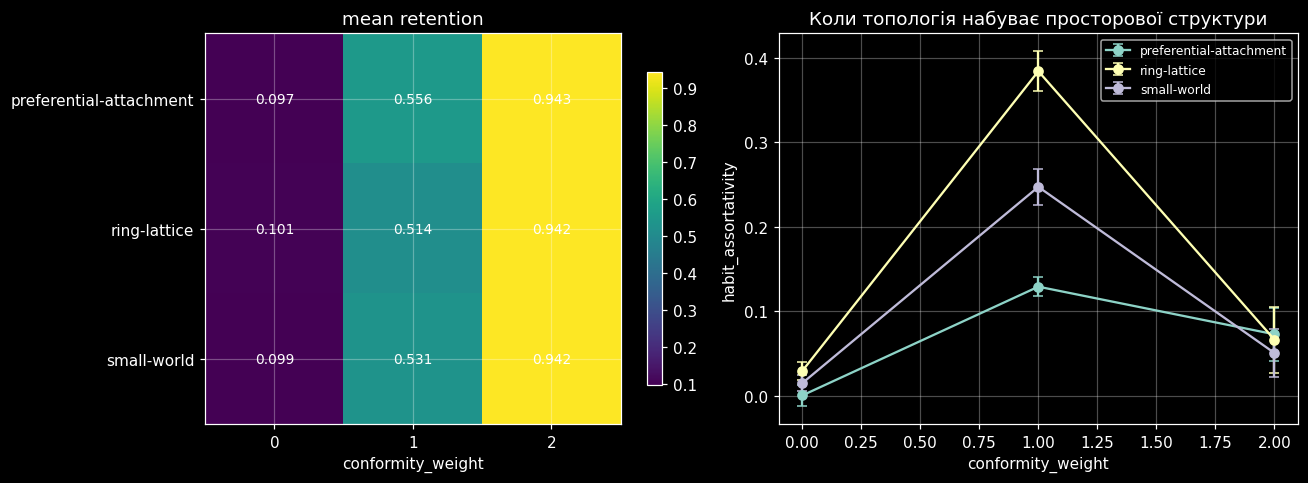

In [8]:
e5 = data["e5"]
if e5 is None:
    print("e5-table.csv відсутній — розділ пропущено.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    piv = e5.pivot_table(index="network_topology", columns="conformity_weight",
                          values="retention", aggfunc="mean")
    im = axes[0].imshow(piv.values, aspect="auto", cmap="viridis")
    axes[0].set_xticks(range(len(piv.columns))); axes[0].set_xticklabels(piv.columns)
    axes[0].set_yticks(range(len(piv.index))); axes[0].set_yticklabels(piv.index)
    axes[0].set_xlabel("conformity_weight"); axes[0].set_title("mean retention")
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            axes[0].text(j, i, f"{piv.values[i, j]:.3f}", ha="center", va="center",
                          color="white", fontsize=9)
    fig.colorbar(im, ax=axes[0], shrink=0.8)

    s = summarize(e5, ["network_topology", "conformity_weight"], "habit_assortativity")
    for topo, g in s.groupby("network_topology", observed=True):
        axes[1].errorbar(g["conformity_weight"], g["mean"],
                          yerr=[g["mean"] - g["ci_lo"], g["ci_hi"] - g["mean"]],
                          marker="o", capsize=3, label=topo)
    axes[1].set_xlabel("conformity_weight"); axes[1].set_ylabel("habit_assortativity")
    axes[1].set_title("Коли топологія набуває просторової структури")
    axes[1].legend(fontsize=8)

    fig.tight_layout()
    maybe_save(fig, "e5_topology_conformity")
    plt.show()

## E6 — Initial opinion distribution

Дві окремі перевірки одним прогоном:

1. **Чи виживає поляризація** — `opinion_standard_deviation` наприкінці
   прогону, за `initial-opinion-distribution` × `confidence-bound`.
2. **Чи ця поляризація взагалі дістається до поведінки** — контрастуємо
   `campaign_lift`/`retention` за `initial-opinion-distribution` окремо
   для `opinion-weight = 0` (канал закритий, різниць бути не повинно)
   і `opinion-weight = 1` (канал відкритий).

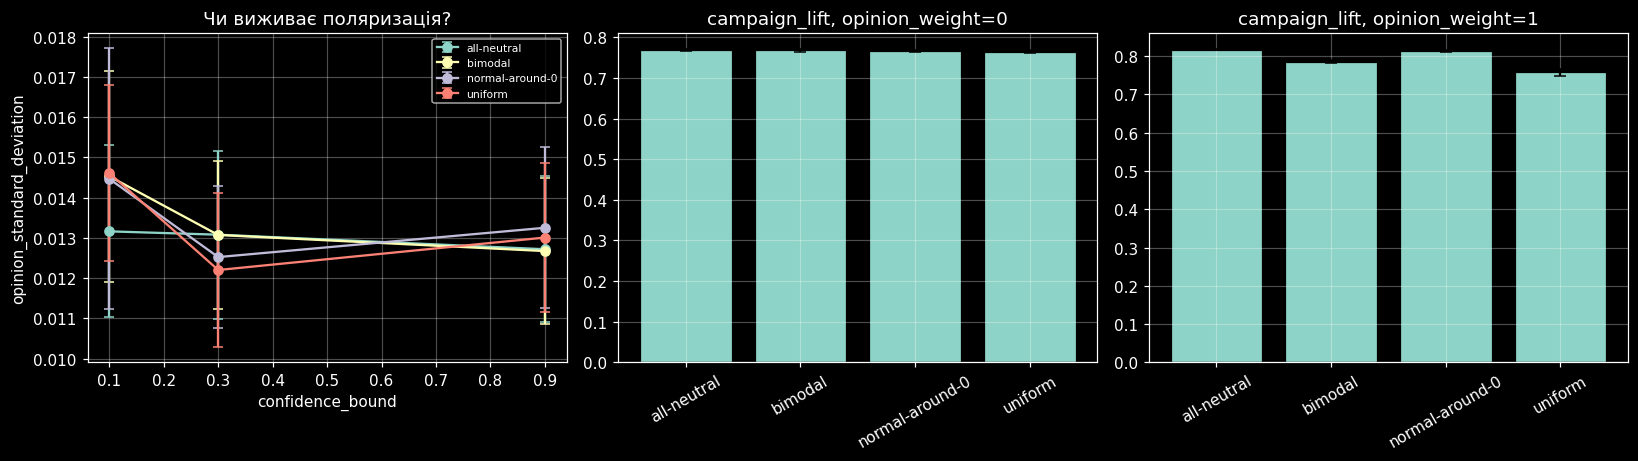

Перевірка контролю (opinion_weight=0 має давати ~однакові campaign_lift для всіх розподілів, бо канал закритий):
  initial_opinion_distribution      mean     ci_lo     ci_hi
0                  all-neutral  0.768820  0.766200  0.771441
1                      bimodal  0.767491  0.764878  0.770103
2              normal-around-0  0.766532  0.764046  0.769017
3                      uniform  0.764195  0.761006  0.767384


In [9]:
e6 = data["e6"]
if e6 is None:
    print("e6-table.csv відсутній — розділ пропущено.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

    s = summarize(e6, ["initial_opinion_distribution", "confidence_bound"], "opinion_standard_deviation")
    for dist, g in s.groupby("initial_opinion_distribution", observed=True):
        axes[0].errorbar(g["confidence_bound"], g["mean"],
                          yerr=[g["mean"] - g["ci_lo"], g["ci_hi"] - g["mean"]],
                          marker="o", capsize=3, label=dist)
    axes[0].set_xlabel("confidence_bound"); axes[0].set_ylabel("opinion_standard_deviation")
    axes[0].set_title("Чи виживає поляризація?")
    axes[0].legend(fontsize=7)

    for ax, ow in zip(axes[1:], [0, 1]):
        sub = e6[e6.opinion_weight == ow]
        s2 = summarize(sub, ["initial_opinion_distribution"], "campaign_lift")
        bar_with_ci(ax, s2, labels=s2["initial_opinion_distribution"],
                    title=f"campaign_lift, opinion_weight={ow}")
        ax.tick_params(axis="x", rotation=30)

    fig.tight_layout()
    maybe_save(fig, "e6_initial_opinion_distribution")
    plt.show()

    print("Перевірка контролю (opinion_weight=0 має давати ~однакові campaign_lift "
          "для всіх розподілів, бо канал закритий):")
    print(summarize(e6[e6.opinion_weight == 0], ["initial_opinion_distribution"], "campaign_lift")
          [["initial_opinion_distribution", "mean", "ci_lo", "ci_hi"]])

## E7 — Big factorial

Найбільший експеримент сюїти (~28 800 прогонів). Якщо `e7-table.csv` ще
не готовий, цей розділ просто друкує повідомлення і нічого не ламає —
решта ноутбука не залежить від E7.

e7: 28800 рядків, 28800 прогонів


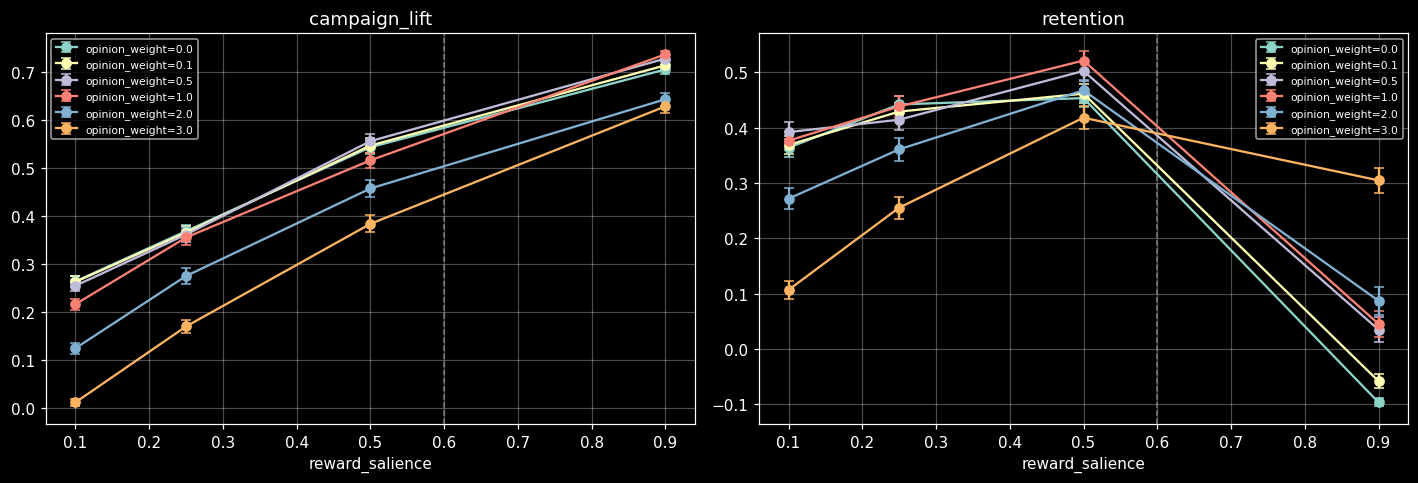


Це лише загальний огляд по двох з п'яти факторів (reward_salience x opinion_weight). confidence_bound, initial_opinion_distribution і conformity_weight теж варіюються в e7 — додайте groupby/facet по них для конкретнішого питання, коли визначитесь, яке саме цікавить.


In [10]:
e7 = data["e7"]
if e7 is None:
    print("e7-table.csv відсутній — E7 ще рахується. Розділ пропущено; "
          "перезапустіть ноутбук, коли файл з'явиться поруч із рештою.")
else:
    print(f"e7: {len(e7)} рядків, {e7['run_number'].nunique()} прогонів")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for ax, m in zip(axes, ["campaign_lift", "retention"]):
        for ow in sorted(e7["opinion_weight"].unique()):
            sub = e7[e7.opinion_weight == ow]
            s = summarize(sub, ["reward_salience"], m)
            ax.errorbar(s["reward_salience"], s["mean"],
                        yerr=[s["mean"] - s["ci_lo"], s["ci_hi"] - s["mean"]],
                        marker="o", capsize=3, label=f"opinion_weight={ow}")
        ax.axvline(SALIENCE_THRESHOLD, color="gray", linestyle="--", linewidth=1)
        ax.set_xlabel("reward_salience"); ax.set_title(m)
        ax.legend(fontsize=7)
    fig.tight_layout()
    maybe_save(fig, "e7_big_factorial_overview")
    plt.show()

    print("\nЦе лише загальний огляд по двох з п'яти факторів (reward_salience x "
          "opinion_weight). confidence_bound, initial_opinion_distribution і "
          "conformity_weight теж варіюються в e7 — додайте groupby/facet по них "
          "для конкретнішого питання, коли визначитесь, яке саме цікавить.")

### E7 — conformity_weight × opinion_weight

Два соціальні канали моделі — поведінкова конформність
(`conformity_weight`, через `neighbor-target-share`) і думки
(`opinion_weight`, через bounded-confidence динаміку) — у E5 і E6
варіювались по черзі, з іншим каналом зафіксованим на 1.0. E7 варіює
обидва одночасно, тож тут можна побачити, чи підсилюють вони один
одного скрізь, чи є комбінації, де взаємне підсилення двох каналів
шкодить, а не допомагає.

retention: максимум при conformity_weight=1.0, opinion_weight=0.5 (0.568)  <- усередині сітки, не на межі: ефект немонотонний
campaign_lift: максимум при conformity_weight=1.0, opinion_weight=0.1 (0.669)  <- усередині сітки, не на межі: ефект немонотонний


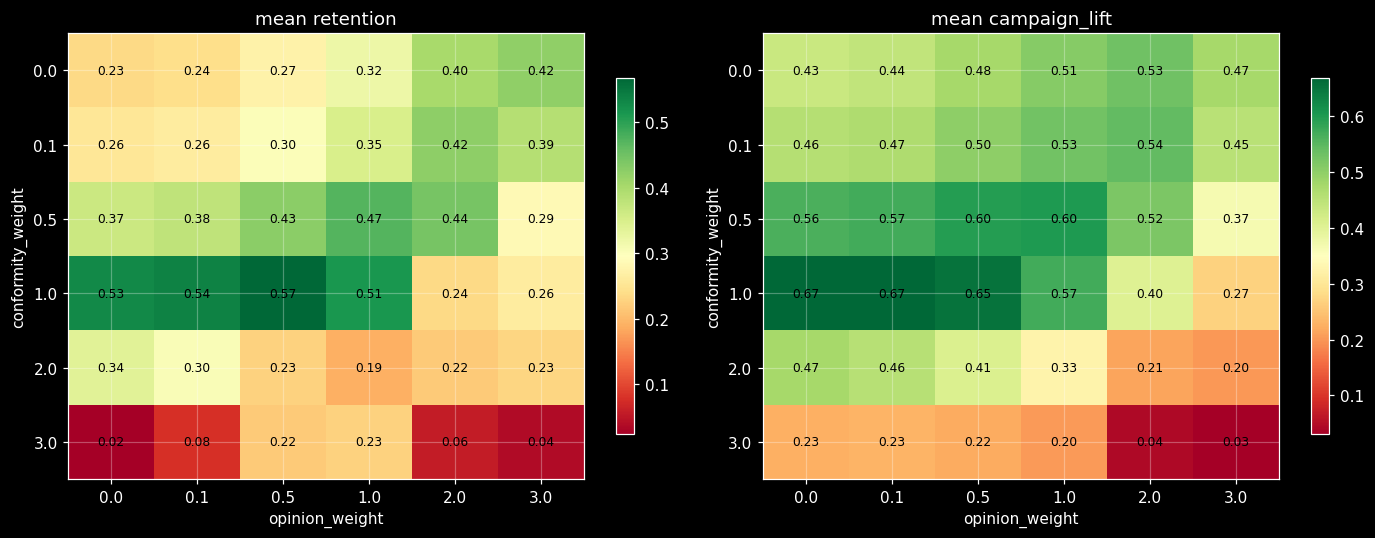

In [11]:
if e7 is None:
    print("e7-table.csv відсутній — розділ пропущено.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, m in zip(axes, ["retention", "campaign_lift"]):
        piv = e7.pivot_table(index="conformity_weight", columns="opinion_weight",
                              values=m, aggfunc="mean")
        im = ax.imshow(piv.values, aspect="auto", cmap="RdYlGn", vmin=piv.values.min(),
                        vmax=piv.values.max())
        ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
        ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
        ax.set_xlabel("opinion_weight"); ax.set_ylabel("conformity_weight")
        ax.set_title(f"mean {m}")
        for i in range(piv.shape[0]):
            for j in range(piv.shape[1]):
                ax.text(j, i, f"{piv.values[i, j]:.2f}", ha="center", va="center",
                        color="black", fontsize=8)
        fig.colorbar(im, ax=ax, shrink=0.8)

        # чи пік лежить усередині сітки, а не на її межі — ознака
        # немонотонної, а не просто "більше завжди краще" взаємодії.
        i_max, j_max = np.unravel_index(np.nanargmax(piv.values), piv.values.shape)
        on_edge = i_max in (0, piv.shape[0] - 1) and j_max in (0, piv.shape[1] - 1)
        print(f"{m}: максимум при conformity_weight={piv.index[i_max]}, "
              f"opinion_weight={piv.columns[j_max]} ({piv.values[i_max, j_max]:.3f})"
              + ("" if on_edge else "  <- усередині сітки, не на межі: ефект немонотонний"))

    fig.tight_layout()
    maybe_save(fig, "e7_conformity_x_opinion_heatmap")
    plt.show()

## Підсумок

Обчислюється з реальних даних вище, а не вписано вручну.

In [12]:
summary_rows = []

if e1 is not None:
    r = compare_two_groups(e1, "wom_on", "campaign_lift")
    summary_rows.append(dict(
        question="E1 Amplification",
        finding=f"campaign_lift {'вище' if r['diff'] > 0 else 'нижче'} на {r['diff']:.3f} при wom on",
        effect_size=f"Cohen's d = {r['cohens_d']:.2f}",
        p_value=f"p = {r['p_mannwhitney']:.2e}",
    ))

if e1 is not None:
    r = compare_two_groups(e1, "wom_on", "retention")
    summary_rows.append(dict(
        question="E2 Persistence (рівень, з E1)",
        finding=f"retention {'вище' if r['diff'] > 0 else 'нижче'} на {r['diff']:.3f} при wom on",
        effect_size=f"Cohen's d = {r['cohens_d']:.2f}",
        p_value=f"p = {r['p_mannwhitney']:.2e}",
    ))

if e3 is not None:
    interaction = e3_summary.loc["retention", "interaction"]
    summary_rows.append(dict(
        question="E3 Substitution",
        finding=("канали замінники (суб'адитивно)" if interaction < 0 else "канали доповнювачі (супрадитивно)")
                 + f", взаємодія = {interaction:.3f}",
        effect_size="—",
        p_value="ANOVA/bootstrap вище",
    ))

if e6 is not None:
    ctrl = summarize(e6[e6.opinion_weight == 0], ["initial_opinion_distribution"], "campaign_lift")
    spread = ctrl["mean"].max() - ctrl["mean"].min()
    summary_rows.append(dict(
        question="E6 контроль (opinion_weight=0)",
        finding=f"розкид campaign_lift між розподілами = {spread:.4f} (має бути ≈0)",
        effect_size="—", p_value="—",
    ))

if summary_rows:
    display(pd.DataFrame(summary_rows).set_index("question"))
else:
    print("Жодного файлу даних не знайдено.")

,finding,effect_size,p_value
question,,,
E1 Amplification,campaign_lift вище на 0.046 при wom on,Cohen's d = 3.89,p = 1.67e-14
"E2 Persistence (рівень, з E1)",retention вище на 0.156 при wom on,Cohen's d = 7.01,p = 1.43e-14
E3 Substitution,"канали доповнювачі (супрадитивно), взаємодія =...",—,ANOVA/bootstrap вище
E6 контроль (opinion_weight=0),розкид campaign_lift між розподілами = 0.0046 ...,—,—
